In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [3]:
df=pd.read_csv("/workspaces/Aress_Task/data/Churn_preprocssing.csv")

In [4]:
X=df.drop(['Exited'],axis=1)
y=df['Exited']

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [17]:
pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('model',RandomForestClassifier(n_estimators=100))])

pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)

Report of Random Forest
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.45      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000

Confusion Matrix


Text(50.722222222222214, 0.5, 'Predicted')

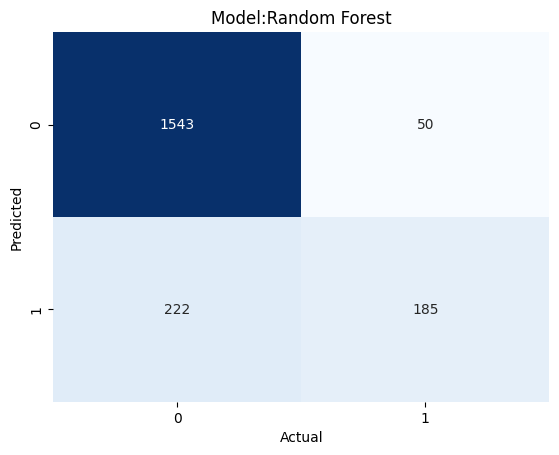

In [18]:
print("Report of Random Forest")
print(classification_report(y_test, y_pred))
print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Model:Random Forest")    
plt.xlabel("Actual")
plt.ylabel('Predicted')

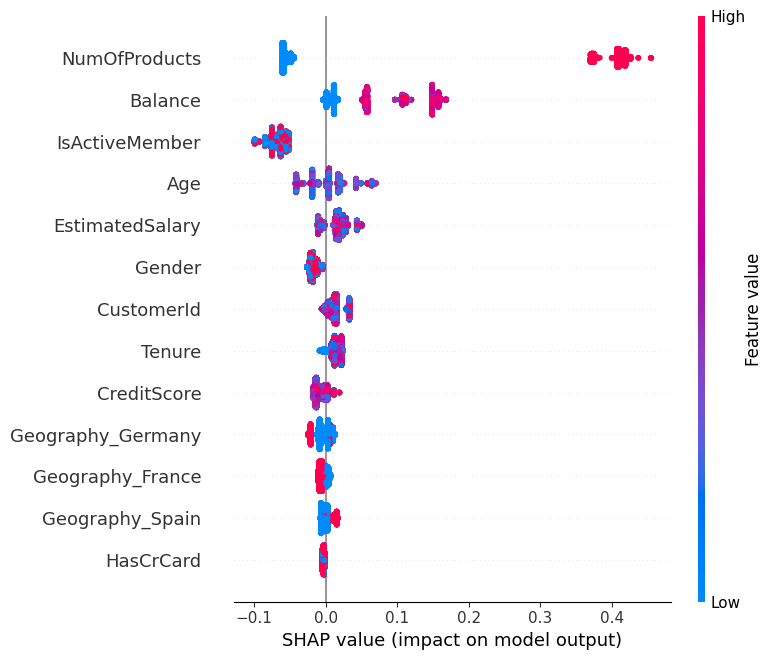

In [20]:
## Implementing SHAP
import shap
model=pipeline.named_steps['model']

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)
shap.summary_plot(shap_values[:, :, 1], X_train)

In [27]:
from lime.lime_tabular import LimeTabularExplainer

path = r'/workspaces/Aress_Task/data'
X_train_np = X_train.values
feature_names = X_train.columns.tolist()
class_names = ['not_exited', 'exited']

explainer_lime = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

# Explain a single instance
idx = 0
instance = X_test.iloc[idx].values.reshape(1, -1)

exp = explainer_lime.explain_instance(
    data_row=instance.flatten(),
    predict_fn=pipeline.predict_proba,
    num_features=10
)

print("Top features (LIME):", exp.as_list())

# Save explanation to HTML file
exp.save_to_file('/workspaces/Aress_Task/data/lime_explanation.html')


Top features (LIME): [('1.00 < NumOfProducts <= 2.00', -0.13704221935631083), ('32.00 < Age <= 37.00', -0.11911746036204451), ('IsActiveMember <= 0.00', 0.11217590100804208), ('0.00 < Gender <= 1.00', -0.04155665389574583), ('Geography_Germany <= 0.00', -0.03326348645439894), ('0.00 < Geography_France <= 1.00', -0.018596362385009734), ('Balance <= 0.00', -0.017927483442585785), ('Geography_Spain <= 0.00', 0.01580713915776516), ('0.00 < HasCrCard <= 1.00', -0.014845972757353968), ('15689954.00 < CustomerId <= 15753269.00', -0.01306276545457715)]


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [30]:
import joblib

joblib.dump(pipeline, "churn_model_v1.pkl")

['churn_model_v1.pkl']